# ANN Future OEE Forecasting
4 separate horizon models for OEE prediction using TensorFlow/Keras.


## 1. Environment Setup
Install required dependencies. Run this cell first if packages are missing.


In [1]:
# Install dependencies (uncomment and run if needed)
!python -m pip install pandas numpy matplotlib seaborn scikit-learn tensorflow joblib

### 1.1 Imports


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Exploration
Load the synthetic time-series OEE dataset. The data contains 6 input features and 5 target horizons (30m, 1h, 2h, 6h, 8h).


In [4]:
df = pd.read_csv('data/syn_timeseries_oee.csv')
print(f'Shape: {df.shape}')
display(df.head())
print(f'\nNull counts:\n{df.isnull().sum()}')


Shape: (19520, 12)


,timestamp,rpm,availability,performance,quality,current_oee,downtime_minutes,target_oee_30m,target_oee_1h,target_oee_2h,target_oee_6h,target_oee_8h
0,2026-01-01 00:00:00,0.0,88.00,82.00,86.00,62.06,0.0,60.49,65.28,66.63,66.45,66.37
1,2026-01-01 00:01:00,300.0,87.67,82.09,86.07,61.94,0.0,60.87,66.49,66.52,66.10,66.61
2,2026-01-01 00:02:00,301.2,87.97,81.95,86.21,62.14,0.0,60.85,66.22,66.13,66.60,66.38
3,2026-01-01 00:03:00,300.0,87.80,81.67,85.55,61.34,0.0,61.40,65.57,65.63,66.38,66.51
4,2026-01-01 00:04:00,300.0,88.08,81.36,85.63,61.37,0.0,61.17,65.69,66.34,66.81,66.98



Null counts:
timestamp           0
rpm                 0
availability        0
performance         0
quality             0
current_oee         0
downtime_minutes    0
target_oee_30m      0
target_oee_1h       0
target_oee_2h       0
target_oee_6h       0
target_oee_8h       0
dtype: int64


## 3. Feature Engineering & Preprocessing
### 3.1 Feature & Target Definition
- **Inputs**: rpm, availability, performance, quality, current_oee, downtime_minutes
- **Targets**: future OEE at 30-minute, 1-hour, 2-hour, 6-hour, and 8-hour horizons
### 3.2 Train/Val/Test Split
- **80%** training (15,616 samples)
- **10%** validation (1,952 samples)  
- **10%** test (1,952 samples)
### 3.3 Standardization
Features are z-score normalized using `StandardScaler`. The scaler is fit on training data only and saved for API inference.


In [5]:
features = ['rpm', 'availability', 'performance', 'quality', 'current_oee', 'downtime_minutes']

targets = {
    '30m': 'target_oee_30m',
    '1h':  'target_oee_1h',
    '2h':  'target_oee_2h',
    '6h':  'target_oee_6h',
    '8h':  'target_oee_8h',
}

X = df[features].values

n = len(df)
train_end = int(0.8 * n)
val_end   = int(0.9 * n)

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')


Train: 15616, Val: 1952, Test: 1952


## 4. Model Architecture
Each horizon has its own independent ANN with identical architecture:
| Layer | Type | Units | Activation |
|-------|------|-------|------------|
| 1 | Dense | 64 | ReLU |
| 2 | Dropout | 0.2 | — |
| 3 | Dense | 32 | ReLU |
| 4 | Dropout | 0.1 | — |
| 5 | Dense | 16 | ReLU |
| 6 | Dense | 1 | Linear |
- **Optimizer**: Adam (lr=0.001)
- **Loss**: Mean Squared Error
- **Early Stopping**: patience=10, restore best weights


In [6]:
# Train one model per horizon individually to avoid timeout
results = []
histories = {}
y_test_dict = {}
y_pred_dict = {}
best_models = {}

def build_oee_model(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model


## 5. Model Training
Each horizon is trained independently in separate cells to:
- Allow incremental execution / checkpointing
- Avoid MCP timeouts from combined output
- Isolate horizon-specific results
Training applies EarlyStopping (patience=10) on validation loss to prevent overfitting.


### 30-minute Horizon


In [7]:
# --- Train 30m horizon ---
horizon, col = '30m', targets['30m']
y = df[col].values
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]
y_test_dict[horizon] = y_test

model = build_oee_model(X_train_s.shape[1])
es = EarlyStopping(patience=10, restore_best_weights=True, min_delta=1e-5)
h = model.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
              epochs=100, batch_size=32, callbacks=[es], verbose=0)
histories[horizon] = h
best_models[horizon] = model

y_pred = model.predict(X_test_s, verbose=0).flatten()
y_pred_dict[horizon] = y_pred

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100
results.append({'Horizon': horizon, 'R²': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape})
print(f'\n30m — R²: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%')



30m — R²: 0.8106, MAE: 1.4565, RMSE: 1.8143, MAPE: 2.36%


### 1-hour Horizon


In [8]:
# --- Train 1h horizon ---
horizon, col = '1h', targets['1h']
y = df[col].values
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]
y_test_dict[horizon] = y_test

model = build_oee_model(X_train_s.shape[1])
es = EarlyStopping(patience=10, restore_best_weights=True, min_delta=1e-5)
h = model.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
              epochs=100, batch_size=32, callbacks=[es], verbose=0)
histories[horizon] = h
best_models[horizon] = model

y_pred = model.predict(X_test_s, verbose=0).flatten()
y_pred_dict[horizon] = y_pred

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100
results.append({'Horizon': horizon, 'R²': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape})
print(f'\n1h — R²: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%')



1h — R²: 0.6530, MAE: 1.9349, RMSE: 2.4410, MAPE: 3.12%


### 2-hour Horizon


In [9]:
# --- Train 2h horizon ---
horizon, col = '2h', targets['2h']
y = df[col].values
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]
y_test_dict[horizon] = y_test

model = build_oee_model(X_train_s.shape[1])
es = EarlyStopping(patience=10, restore_best_weights=True, min_delta=1e-5)
h = model.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
              epochs=100, batch_size=32, callbacks=[es], verbose=0)
histories[horizon] = h
best_models[horizon] = model

y_pred = model.predict(X_test_s, verbose=0).flatten()
y_pred_dict[horizon] = y_pred

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100
results.append({'Horizon': horizon, 'R²': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape})
print(f'\n2h — R²: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%')



2h — R²: 0.3489, MAE: 2.5458, RMSE: 3.2604, MAPE: 4.10%


### 6-hour Horizon


In [10]:
# --- Train 6h horizon ---
horizon, col = '6h', targets['6h']
y = df[col].values
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]
y_test_dict[horizon] = y_test

model = build_oee_model(X_train_s.shape[1])
es = EarlyStopping(patience=10, restore_best_weights=True, min_delta=1e-5)
h = model.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
              epochs=100, batch_size=32, callbacks=[es], verbose=0)
histories[horizon] = h
best_models[horizon] = model

y_pred = model.predict(X_test_s, verbose=0).flatten()
y_pred_dict[horizon] = y_pred

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100
results.append({'Horizon': horizon, 'R²': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape})
print(f'\n6h — R²: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%')



6h — R²: -0.7089, MAE: 3.4692, RMSE: 4.1336, MAPE: 5.90%


### 8-hour Horizon


In [11]:
# --- Train 8h horizon ---
horizon, col = '8h', targets['8h']
y = df[col].values
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]
y_test_dict[horizon] = y_test

model = build_oee_model(X_train_s.shape[1])
es = EarlyStopping(patience=10, restore_best_weights=True, min_delta=1e-5)
h = model.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
              epochs=100, batch_size=32, callbacks=[es], verbose=0)
histories[horizon] = h
best_models[horizon] = model

y_pred = model.predict(X_test_s, verbose=0).flatten()
y_pred_dict[horizon] = y_pred

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100
results.append({'Horizon': horizon, 'R²': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape})
print(f'\n8h — R²: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%')



8h — R²: -0.4156, MAE: 3.0151, RMSE: 3.5669, MAPE: 5.09%


## 6. Save Trained Models
All 5 models and the scaler are saved to the `ml_model/models/` directory.
- Models: `ann_oee_{{horizon}}.keras` (TensorFlow SavedModel format)
- Scaler: `scaler.pkl` (joblib)


In [12]:
import os, joblib
from pathlib import Path

# Save relative to this notebook's location
NOTEBOOK_DIR = Path().resolve()  # Jupyter CWD is notebook dir
MODEL_DIR = NOTEBOOK_DIR / 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

for horizon, model in best_models.items():
    path = MODEL_DIR / f'ann_oee_{horizon}.keras'
    model.save(str(path))
    print(f'Saved {path}')

joblib.dump(scaler, str(MODEL_DIR / 'scaler.pkl'))
print(f'Saved {MODEL_DIR / "scaler.pkl"}')


Saved E:\Projects\iot-aiml-project\ml_model\models\ann_oee_30m.keras
Saved E:\Projects\iot-aiml-project\ml_model\models\ann_oee_1h.keras
Saved E:\Projects\iot-aiml-project\ml_model\models\ann_oee_2h.keras
Saved E:\Projects\iot-aiml-project\ml_model\models\ann_oee_6h.keras
Saved E:\Projects\iot-aiml-project\ml_model\models\ann_oee_8h.keras
Saved E:\Projects\iot-aiml-project\ml_model\models\scaler.pkl


## 7. Performance Results
Metrics table showing R², MAE, RMSE, and MAPE for each horizon.


In [13]:
results_df = pd.DataFrame(results).set_index('Horizon')
print('\n' + '='*60)
print('MODEL PERFORMANCE SUMMARY')
print('='*60)
print(results_df.to_string())
print('='*60)



MODEL PERFORMANCE SUMMARY
               R²       MAE      RMSE  MAPE (%)
Horizon                                        
30m      0.810613  1.456465  1.814330  2.364111
1h       0.653049  1.934898  2.440966  3.115237
2h       0.348894  2.545819  3.260395  4.100946
6h      -0.708887  3.469179  4.133634  5.897341
8h      -0.415598  3.015099  3.566915  5.085133


## 8. Visualizations
### 8.1 Actual vs Predicted Scatter
- Perfect predictions follow the red dashed line
- Point cloud tightness indicates prediction quality
### 8.2 Performance Metrics by Horizon
- R² bar chart (higher = better)
- MAE bar chart (lower = better)
### 8.3 Time-Series Overlay
First 200 test samples showing actual vs all 5 horizon predictions.


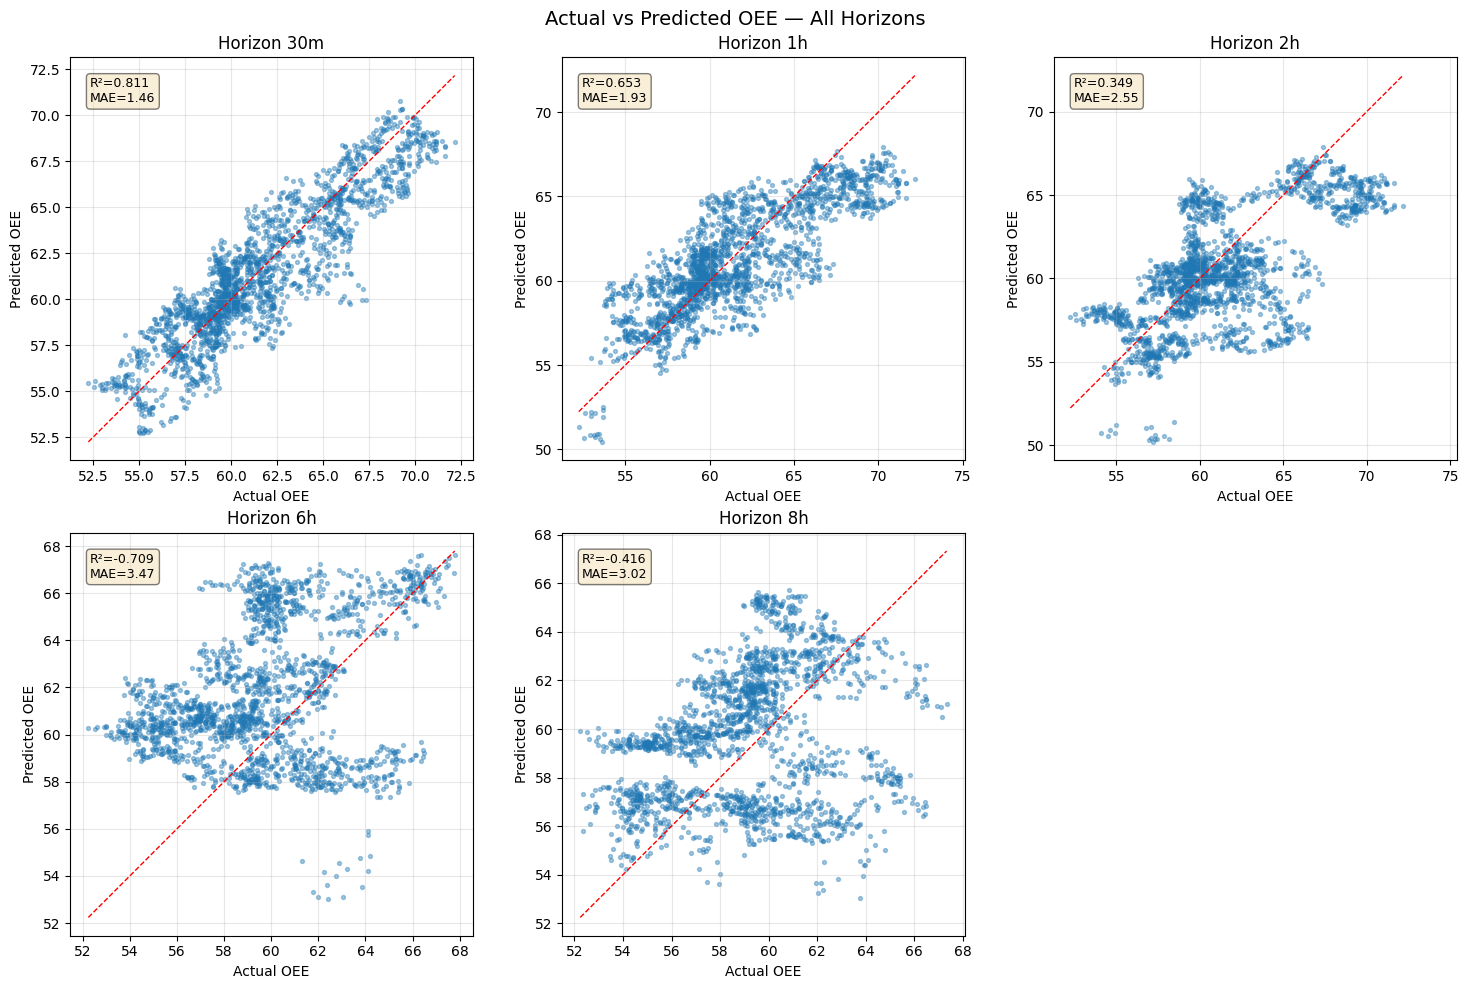

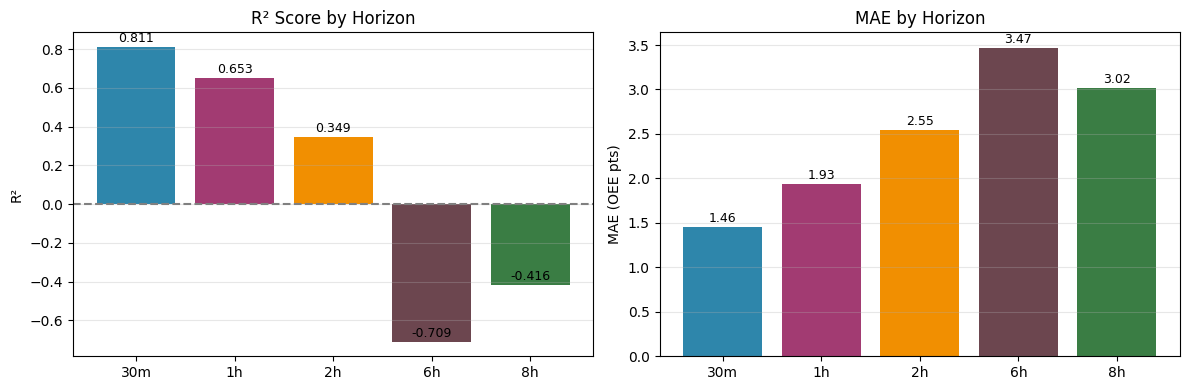

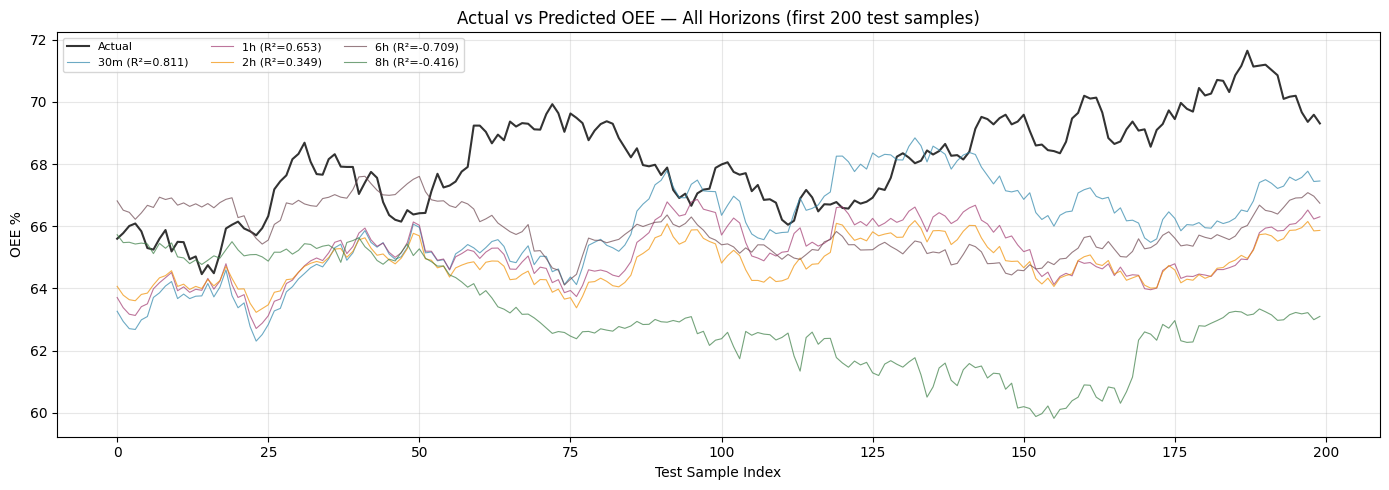

In [14]:
# === FIGURE 1: Actual vs Predicted Scatter ===
fig1, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, (horizon, _) in enumerate(targets.items()):
    ax = axes[i]
    ax.scatter(y_test_dict[horizon], y_pred_dict[horizon], alpha=0.4, s=8)
    lims = [min(y_test_dict[horizon]), max(y_test_dict[horizon])]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.text(0.05, 0.95, f'R²={results_df.loc[horizon,"R²"]:.3f}\nMAE={results_df.loc[horizon,"MAE"]:.2f}',
            transform=ax.transAxes, va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_xlabel('Actual OEE')
    ax.set_ylabel('Predicted OEE')
    ax.set_title(f'Horizon {horizon}')
    ax.axis('square')
    ax.grid(True, alpha=0.3)
axes[5].set_visible(False)
fig1.suptitle('Actual vs Predicted OEE — All Horizons', fontsize=14)
plt.tight_layout()
plt.show()

# === FIGURE 2: Performance Metrics by Horizon ===
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bars1 = ax1.bar(results_df.index, results_df['R²'], color=['#2E86AB', '#A23B72', '#F18F01', '#6C464F', '#3A7D44'])
ax1.set_title('R² Score by Horizon', fontsize=12)
ax1.set_ylabel('R²')
ax1.axhline(0, color='gray', ls='--')
for bar, val in zip(bars1, results_df['R²']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}',
             ha='center', va='bottom', fontsize=9)

bars2 = ax2.bar(results_df.index, results_df['MAE'], color=['#2E86AB', '#A23B72', '#F18F01', '#6C464F', '#3A7D44'])
ax2.set_title('MAE by Horizon', fontsize=12)
ax2.set_ylabel('MAE (OEE pts)')
for bar, val in zip(bars2, results_df['MAE']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}',
             ha='center', va='bottom', fontsize=9)

for ax in [ax1, ax2]:
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# === FIGURE 3: Time Series Overlay (all horizons, first 200 test) ===
fig3, ax = plt.subplots(figsize=(14, 5))
x_range = range(200)
ax.plot(x_range, y_test_dict['1h'][:200], 'k-', linewidth=1.5, alpha=0.8, label='Actual')
colors = {'30m': '#2E86AB', '1h': '#A23B72', '2h': '#F18F01', '6h': '#6C464F', '8h': '#3A7D44'}
for horizon in ['30m', '1h', '2h', '6h', '8h']:
    ax.plot(x_range, y_pred_dict[horizon][:200], color=colors[horizon], linewidth=0.8,
            alpha=0.7, label=f'{horizon} (R²={results_df.loc[horizon,"R²"]:.3f})')
ax.set_title('Actual vs Predicted OEE — All Horizons (first 200 test samples)', fontsize=12)
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('OEE %')
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 8.4 Feature Importance Proxy
First-layer weight magnitudes show which input features the model relies on most.


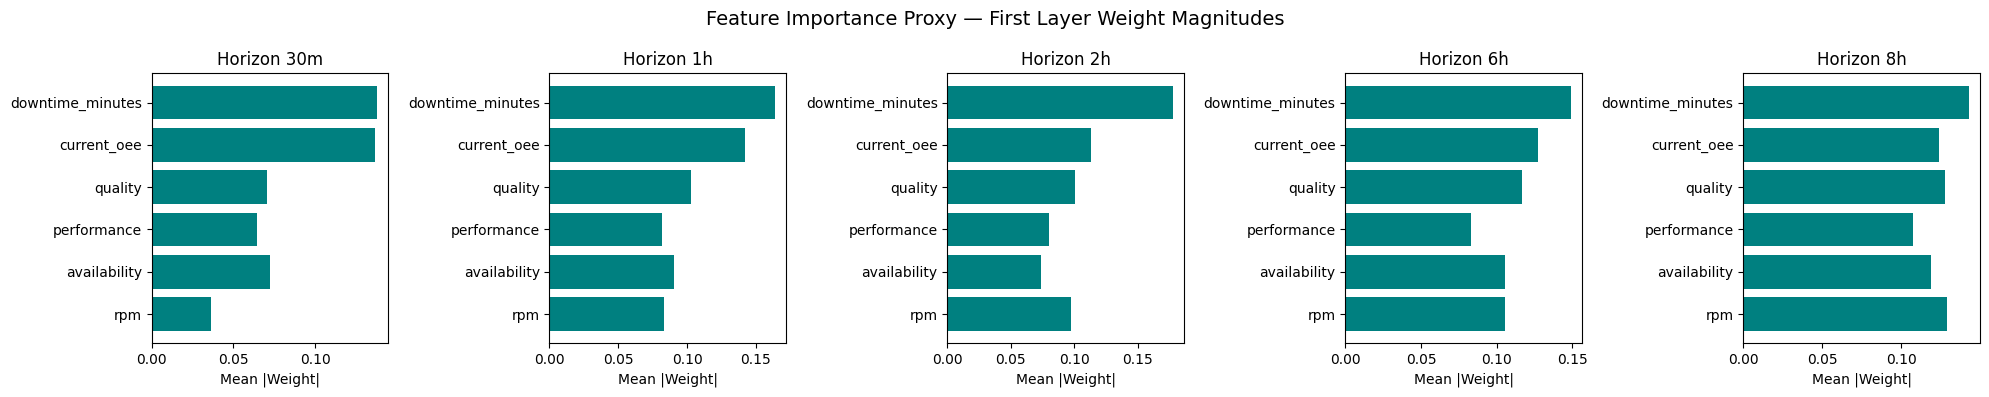

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (horizon, model) in enumerate(best_models.items()):
    w = model.layers[0].get_weights()[0]
    importance = np.mean(np.abs(w), axis=1)
    axes[i].barh(features, importance, color='teal')
    axes[i].set_title(f'Horizon {horizon}')
    axes[i].set_xlabel('Mean |Weight|')

plt.suptitle('Feature Importance Proxy — First Layer Weight Magnitudes', fontsize=14)
plt.tight_layout()
plt.show()


## 9. Comprehensive Diagnostic Evaluation
### 9.1 Training History
- MSE loss curves for all horizons (train vs validation)
- Checks for underfitting/overfitting
### 9.2 Residual Analysis (1h Horizon)
Six-panel diagnostic:
1. Residuals vs Predicted — checks homoscedasticity
2. Residual Histogram — checks normality
3. Q-Q Plot — normality assessment
4. Residual ACF — checks independence
5. Residuals over time — checks for patterns
6. Error magnitude vs prediction — identifies trouble regions
### 9.3 All-Horizons Residual Comparison
- Distribution shape and spread for each horizon
- Bias (mean residual) and uncertainty (std)
### 9.4 Metrics Summary & Quality Checks
- Extended metrics table with residual std and bias
- Overfitting assessment


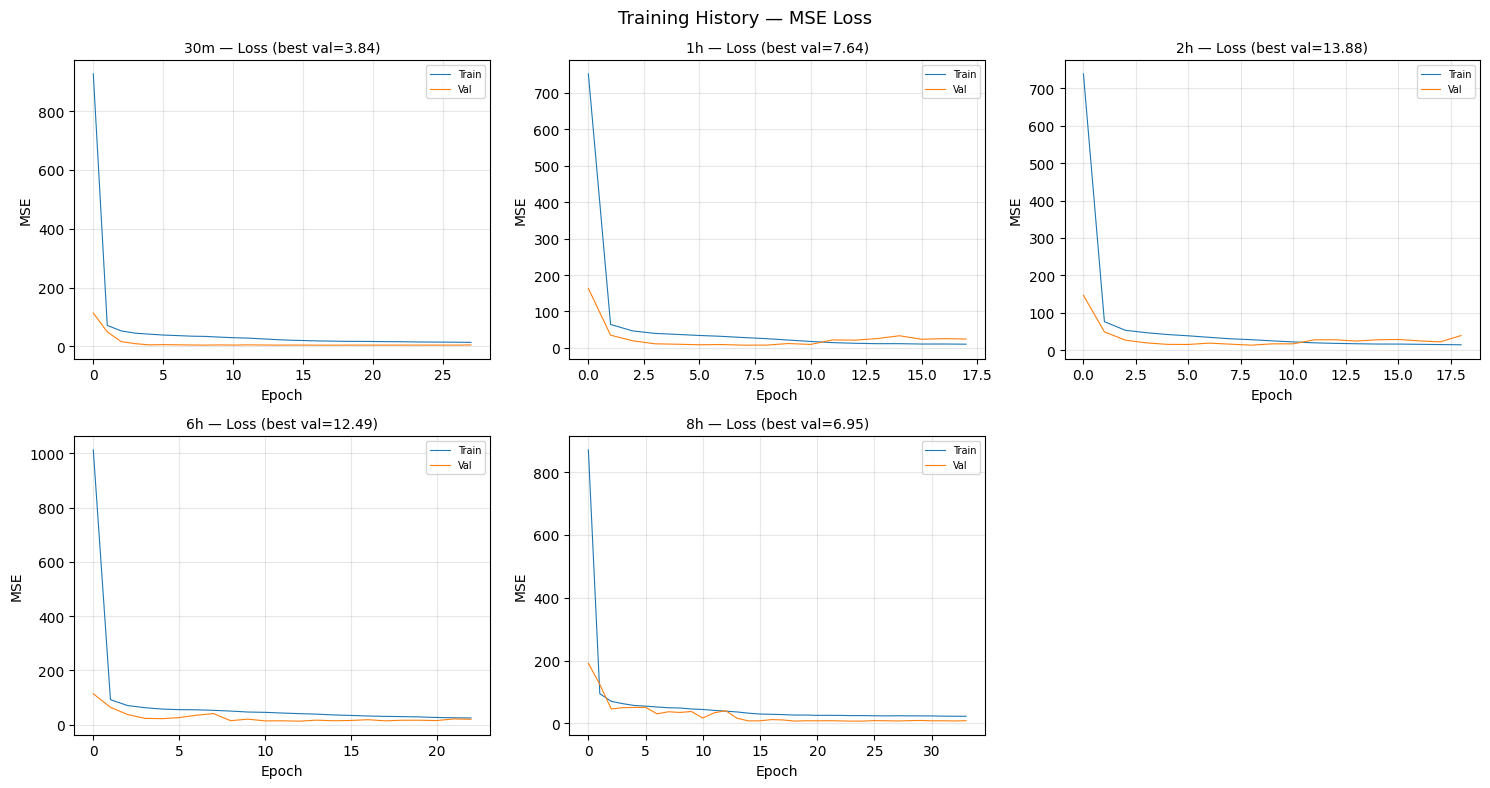

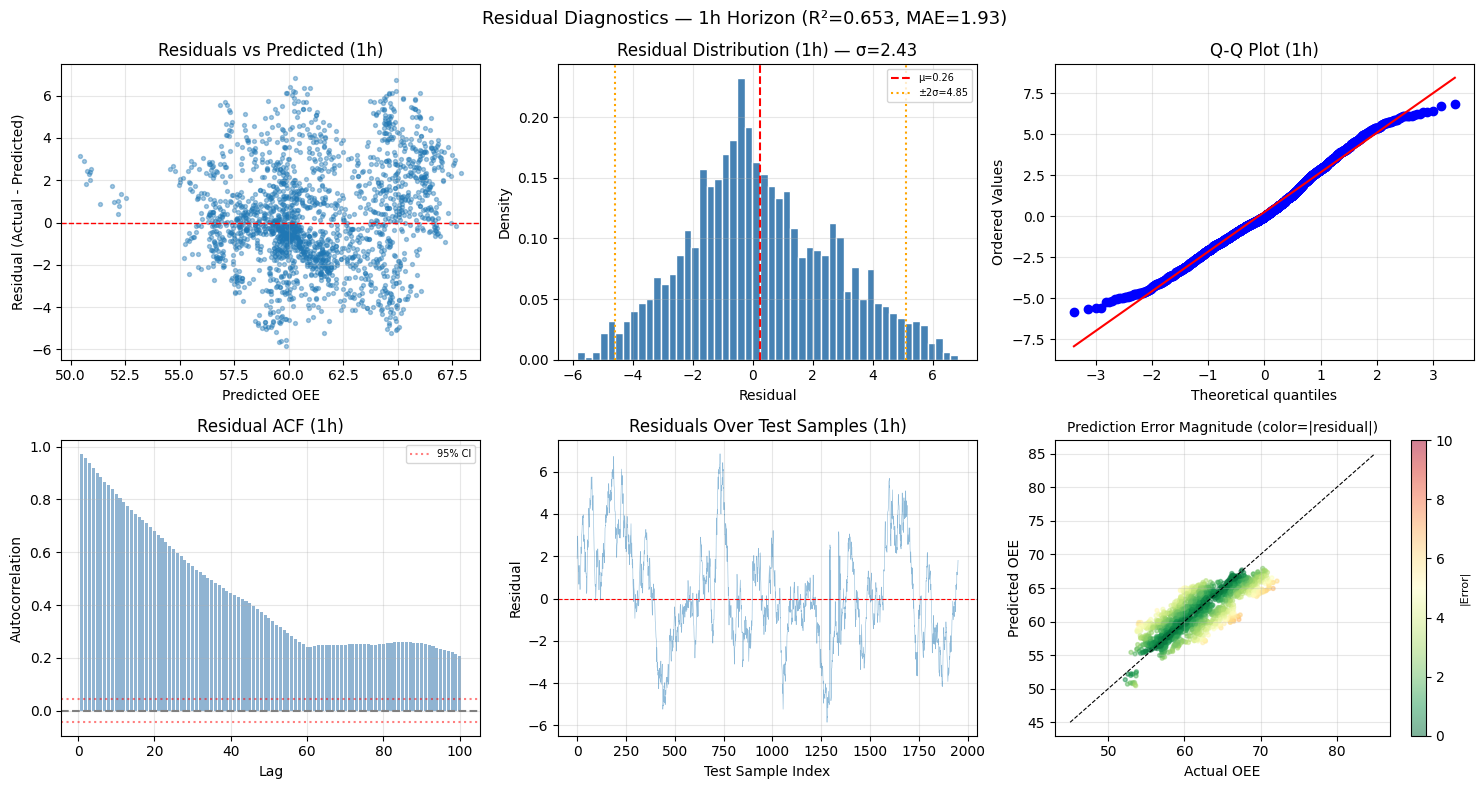

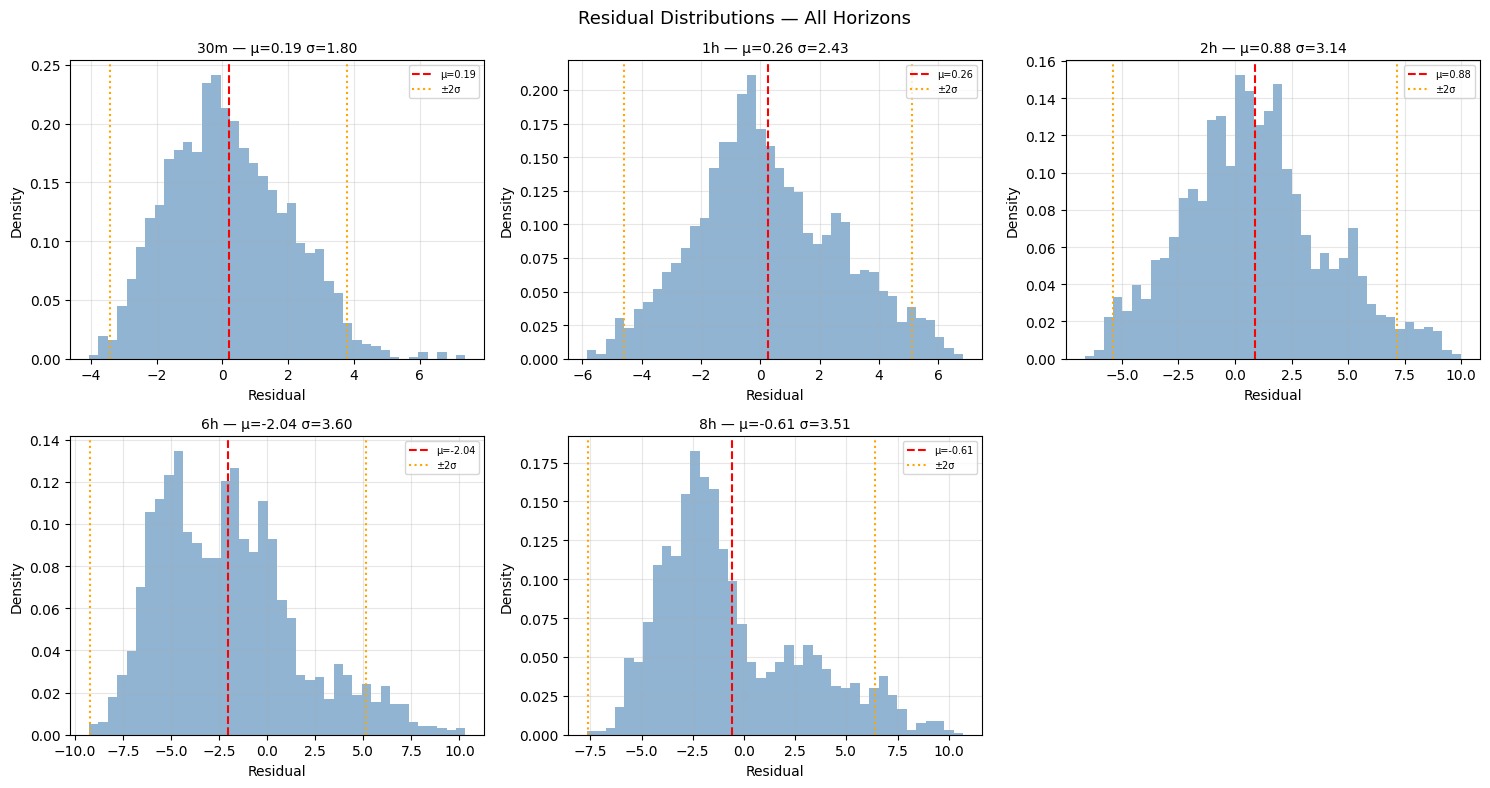


 Horizon       R²        MAE        RMSE      MAPE%     Std_Resid      Bias   
   30m       0.8106      1.46       1.81       2.36        1.80       0.188   
    1h       0.6530      1.93       2.44       3.12        2.43       0.259   
    2h       0.3489      2.55       3.26       4.10        3.14       0.880   
    6h      -0.7089      3.47       4.13       5.90        3.60       -2.037  
    8h      -0.4156      3.02       3.57       5.09        3.51       -0.607  

=== Model Quality Checks ===
  Best 1h model epoch: 18
  Final 1h train loss: 10.3208
  Final 1h val loss:   24.4777
  Overfitting ratio:   2.37x
  Max MAE across horizons: 3.47
  Min R² across horizons:  -0.7089


In [16]:
# ========================================================
# COMPREHENSIVE EVALUATION — Residuals, Training, Diagnostics
# ========================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# --- FIGURE 1: Training History ---
fig1, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, (horizon, _) in enumerate(targets.items()):
    ax = axes[i]
    h = histories[horizon]
    ax.plot(h.history['loss'], label='Train', linewidth=0.8)
    ax.plot(h.history['val_loss'], label='Val', linewidth=0.8)
    ax.set_title(f'{horizon} — Loss (best val={min(h.history["val_loss"]):.2f})', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
axes[5].set_visible(False)
fig1.suptitle('Training History — MSE Loss', fontsize=13)
plt.tight_layout()
plt.show()

# --- FIGURE 2: Residual Analysis (1h horizon) ---
residuals_1h = y_test_dict['1h'] - y_pred_dict['1h']
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# 2a: Residuals vs Predicted
axes[0].scatter(y_pred_dict['1h'], residuals_1h, alpha=0.4, s=8)
axes[0].axhline(0, color='red', ls='--', lw=1)
axes[0].set_xlabel('Predicted OEE')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted (1h)')
axes[0].grid(True, alpha=0.3)

# 2b: Residual histogram
axes[1].hist(residuals_1h, bins=50, color='steelblue', edgecolor='white', density=True)
mu_r, std_r = residuals_1h.mean(), residuals_1h.std()
axes[1].axvline(mu_r, color='red', ls='--', label=f'μ={mu_r:.2f}')
axes[1].axvline(mu_r - 2*std_r, color='orange', ls=':', label=f'±2σ={2*std_r:.2f}')
axes[1].axvline(mu_r + 2*std_r, color='orange', ls=':')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Residual Distribution (1h) — σ={std_r:.2f}')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# 2c: Q-Q plot
from scipy import stats
stats.probplot(residuals_1h, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (1h)')
axes[2].grid(True, alpha=0.3)

# 2d: Residual autocorrelation
lags = list(range(1, 101))
ac_res = [pd.Series(residuals_1h).autocorr(lag=l) for l in lags]
axes[3].bar(lags, ac_res, width=0.8, color='steelblue', alpha=0.6)
axes[3].axhline(0, color='gray', ls='--')
axes[3].axhline(1.96/np.sqrt(len(residuals_1h)), color='red', ls=':', alpha=0.5, label='95% CI')
axes[3].axhline(-1.96/np.sqrt(len(residuals_1h)), color='red', ls=':', alpha=0.5)
axes[3].set_title('Residual ACF (1h)')
axes[3].set_xlabel('Lag')
axes[3].set_ylabel('Autocorrelation')
axes[3].legend(fontsize=7)
axes[3].grid(True, alpha=0.3)

# 2e: Residuals over time (test order)
axes[4].plot(range(len(residuals_1h)), residuals_1h, alpha=0.5, linewidth=0.4)
axes[4].axhline(0, color='red', ls='--', lw=0.8)
axes[4].set_title('Residuals Over Test Samples (1h)')
axes[4].set_xlabel('Test Sample Index')
axes[4].set_ylabel('Residual')
axes[4].grid(True, alpha=0.3)

# 2f: Prediction error vs feature values
axes[5].scatter(y_test_dict['1h'], y_pred_dict['1h'], c=np.abs(residuals_1h),
                cmap='RdYlGn_r', s=8, alpha=0.5, vmin=0, vmax=10)
axes[5].plot([45, 85], [45, 85], 'k--', lw=0.8)
axes[5].set_xlabel('Actual OEE')
axes[5].set_ylabel('Predicted OEE')
axes[5].set_title('Prediction Error Magnitude (color=|residual|)', fontsize=10)
cbar = plt.colorbar(axes[5].collections[0], ax=axes[5])
cbar.set_label('|Error|', fontsize=8)
axes[5].grid(True, alpha=0.3)

fig2.suptitle(f'Residual Diagnostics — 1h Horizon (R²={results_df.loc["1h","R²"]:.3f}, MAE={results_df.loc["1h","MAE"]:.2f})', fontsize=13)
plt.tight_layout()
plt.show()

# --- FIGURE 3: All Horizons Residual Comparison ---
fig3, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, (horizon, _) in enumerate(targets.items()):
    ax = axes[i]
    res = y_test_dict[horizon] - y_pred_dict[horizon]
    ax.hist(res, bins=40, alpha=0.6, density=True, color='steelblue')
    mu_r = res.mean()
    std_r = res.std()
    ax.axvline(mu_r, color='red', ls='--', label=f'μ={mu_r:.2f}')
    ax.axvline(mu_r - 2*std_r, color='orange', ls=':', label=f'±2σ')
    ax.axvline(mu_r + 2*std_r, color='orange', ls=':')
    ax.set_title(f'{horizon} — μ={mu_r:.2f} σ={std_r:.2f}', fontsize=10)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
axes[5].set_visible(False)
fig3.suptitle('Residual Distributions — All Horizons', fontsize=13)
plt.tight_layout()
plt.show()

# --- METRICS TABLE ---
print('\n' + '=' * 80)
print(f'{"Horizon":^10} {"R²":^10} {"MAE":^10} {"RMSE":^10} {"MAPE%":^10} {"Std_Resid":^12} {"Bias":^10}')
print('=' * 80)
for _, row in results_df.iterrows():
    horizon = row.name
    y_test_v = y_test_dict[horizon]
    y_pred_v = y_pred_dict[horizon]
    res = y_test_v - y_pred_v
    print(f'{horizon:^10} {row["R²"]:^10.4f} {row["MAE"]:^10.2f} {row["RMSE"]:^10.2f} {row["MAPE (%)"]:^10.2f} {res.std():^12.2f} {res.mean():^10.3f}')
print('=' * 80)

# --- ADDITIONAL QUALITY CHECKS ---
print('\n=== Model Quality Checks ===')
print(f'  Best 1h model epoch: {len(histories["1h"].history["loss"])}')
print(f'  Final 1h train loss: {histories["1h"].history["loss"][-1]:.4f}')
print(f'  Final 1h val loss:   {histories["1h"].history["val_loss"][-1]:.4f}')
print(f'  Overfitting ratio:   {histories["1h"].history["val_loss"][-1]/histories["1h"].history["loss"][-1]:.2f}x')
print(f'  Max MAE across horizons: {results_df["MAE"].max():.2f}')
print(f'  Min R² across horizons:  {results_df["R²"].min():.4f}')
